# Assignment 6

Jesse Perla (University of British Columbia)

## Student Name/Number: (doubleclick to edit)

### Instructions

-   Edit the above cell to include your name and student number.
-   Submit just this `ipynb` to Canvas. Do not rename, it associates your student number with the submission automatically.

In [1]:
using Distributions, Plots, LaTeXStrings, LinearAlgebra, Statistics, Random, QuantEcon, NLsolve

## Question 1

Take the [McCall search model with separation](https://julia.quantecon.org/dynamic_programming/mccall_model_with_separation.html) we discussed in class.

That implemented the following Bellman equation:

$$
V(w) = u(w) + \beta [(1-\alpha)V(w) + \alpha U ]
$$

and

$$
U = u(c) +
  \beta (1 - \gamma) U +
  \beta \gamma \sum_i \max \left\{ U, V(w_i) \right\} p_i
$$

where $\gamma$ is the probability of a job offer while unemployed, $\alpha$ is the probability of exogenous separation, $u$ is the utility function, and $w_i$ is the wage offer with probability $p_i$.

The code which solves for this Bellman Equation is


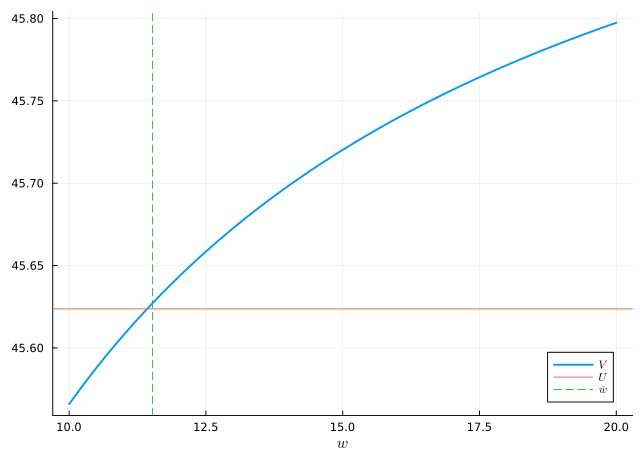

In [1]:
# model constructor
function mccall_model(;
    alpha = 0.2,
    beta = 0.98, # discount rate
    gamma = 0.7,
    c = 6.0, # unemployment compensation
    sigma = 2.0,
    w = range(10, 20, length = 60), # wage values
    dist = BetaBinomial(59, 600, 400)) # distribution over wage values
    return (; alpha, beta, sigma, c, gamma, w, dist, p = pdf.(dist, 0:length(w)-1))
end

function solve_mccall_model(mcm; U_iv = 1.0, V_iv = ones(length(mcm.w)), tol = 1e-5,
                            iter = 2_000)
    (; alpha, beta, sigma, c, gamma, w, sigma, p) = mcm
    u(c) = (c^(1 - sigma) - 1) / (1 - sigma)
    u_w = u.(w)
    u_c = u.(c)

    # Bellman operator T. Fixed point is x* s.t. T(x*) = x*
    function T(x)
        V = x[1:end-1]
        U = x[end]
        # V_p = u_w + beta * ((1 - alpha) * V .+ alpha * U), or expanding out
        V_p = [ u_w[i] + beta * ((1 - alpha) * V[i] + alpha * U) for i in 1:length(w)]
        U_p = u_c + beta * (1 - gamma) * U + beta * gamma * sum(max(U, V[i]) * p[i] for i in 1:length(w))
        return [V_p; U_p]
    end

    # value function iteration
    x_iv = [V_iv; U_iv] # initial x val
    xstar = fixedpoint(T, x_iv, iterations = iter, xtol = tol, m = 0).zero
    V = xstar[1:end-1]
    U = xstar[end]

    # compute the reservation wage
    wbarindex = searchsortedfirst(V .- U, 0.0)
    if wbarindex >= length(w) # if this is true, you never want to accept
        w_bar = Inf
    else
        w_bar = w[wbarindex] # otherwise, return the number
    end

    # return a NamedTuple, so we can select values by name
    return (;V, U, w_bar)
end

mcm = mccall_model()
sol = solve_mccall_model(mcm)

plot(mcm.w, sol.V, lw = 2, label = L"V", xlabel=L"w")
hline!(mcm.w, [sol.U], label=L"U")
vline!([sol.w_bar]; linestyle = :dash, label = L"\bar{w}")

Take the above equation, and consider a variation where there is on-the-job searching for better jobs. With probability $\delta$ the worker gets a job offer while employed

$$
V(w) = u(w) + \beta [(1-\alpha-\delta)V(w) + \alpha U + \delta \sum_i \max \left\{ V(w), V(w_i) \right\} p_i ]
$$

Note that the $\max$ is taken over the current wage and the arrival with the same

$$
U = u(c) +
  \beta (1 - \gamma) U +
  \beta \gamma \sum_i \max \left\{ U, V(w_i) \right\} p_i
$$

Modify the code above to implement this new Bellman equation. Hint: after adding the new constant, you will probably only need to change the `u_w + beta * ((1 - alpha) * V .+ alpha * U)` function to include the new term.


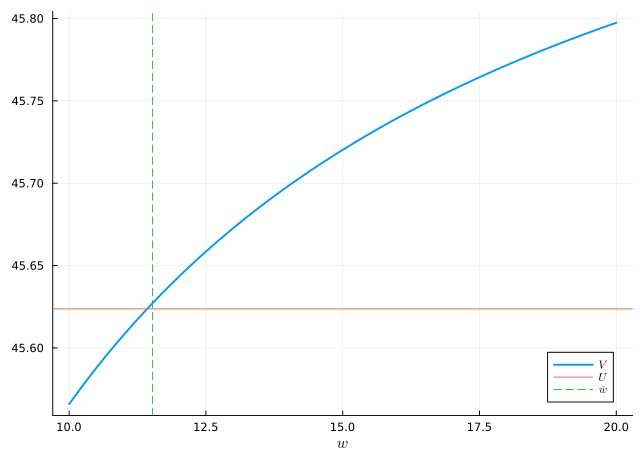

In [1]:
# edit your code here.  Hint: add parameter and look at the T operator
# model constructor
function new_mccall_model(;
    alpha = 0.2,
    beta = 0.98,
    gamma = 0.7,
    delta = 0.1, # NOTE NEW PARAMETER ADDED FOR YOU
    c = 6.0,
    sigma = 2.0,
    w = range(10, 20, length = 60),
    dist = BetaBinomial(59, 600, 400))
    return (; alpha, beta, sigma, delta, c, gamma, w, dist, p = pdf.(dist, 0:length(w)-1))
end

function new_solve_mccall_model(mcm; U_iv = 1.0, V_iv = ones(length(mcm.w)), tol = 1e-5,
                            iter = 2_000)
    (; alpha, beta, sigma, c, gamma, w, sigma, p) = mcm
    u(c) = (c^(1 - sigma) - 1) / (1 - sigma)
    u_w = u.(w)
    u_c = u.(c)

# Bellman operator T. Fixed point is x* s.t. T(x*) = x*
    function T(x)
        V = x[1:end-1]
        U = x[end]
        # V_p = u_w + beta * ((1 - alpha) * V .+ alpha * U), or expanding out
        V_p = [ u_w[i] + beta * ((1 - alpha) * V[i] + alpha * U) for i in 1:length(w)]
        U_p = u_c + beta * (1 - gamma) * U + beta * gamma * sum(max(U, V[i]) * p[i] for i in 1:length(w))
        return [V_p; U_p]
    end

    # value function iteration
    x_iv = [V_iv; U_iv] # initial x val
    xstar = fixedpoint(T, x_iv, iterations = iter, xtol = tol, m = 0).zero
    V = xstar[1:end-1]
    U = xstar[end]

    # compute the reservation wage
    wbarindex = searchsortedfirst(V .- U, 0.0)
    if wbarindex >= length(w) # if this is true, you never want to accept
        w_bar = Inf
    else
        w_bar = w[wbarindex] # otherwise, return the number
    end

    # return a NamedTuple, so we can select values by name
    return (;V, U, w_bar)
end

mcm = new_mccall_model()
sol = new_solve_mccall_model(mcm)

plot(mcm.w, sol.V, lw = 2, label = L"V", xlabel=L"w")
hline!(mcm.w, [sol.U], label=L"U")
vline!([sol.w_bar]; linestyle = :dash, label = L"\bar{w}")